In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data/egx/ABUK.csv")

df.head()

,date,open,high,low,close,volume
0,2015-01-04,10.666666,10.666666,10.666666,10.666666,0
1,2015-01-05,10.666666,10.800000,10.373333,10.794666,295290
2,2015-01-06,10.794666,10.800000,10.800000,10.800000,765000
3,2015-01-08,10.800000,10.400666,10.400666,10.800000,255
4,2015-01-11,10.800000,10.800000,10.800000,10.800000,0


In [47]:
torch.manual_seed(0)
np.random.seed(0)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# We use CLOSE only
series = df["close"].values.astype("float32")

print("Number of data points:", len(series))
print("First 5 close values:")
print(series[:5])

Number of data points: 2857
First 5 close values:
[10.666666 10.794666 10.8      10.8      10.8     ]


In [ ]:
X = series[:-1].reshape(-1, 1)
y = series[1:]

split_point = int(len(series) * 0.7)

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(
    series[:split_point].reshape(-1, 1)
)

series_scaled = scaler.transform(
    series.reshape(-1, 1)
).flatten()


In [60]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp = MLP()

opt = torch.optim.Adam(
    mlp.parameters(),
    lr=0.01
)

for epoch in range(300):
    opt.zero_grad()
    loss = nn.functional.mse_loss( mlp(Xtr), ytr)
    loss.backward()
    opt.step()

mlp_test_loss = nn.functional.mse_loss( mlp(Xte), yte ).item()

persistence_loss = nn.functional.mse_loss( Xte.squeeze(-1), yte).item()

print()
print(f"MLP test loss:              {mlp_test_loss:.5f}")
print(f'"No change" baseline loss:  {persistence_loss:.5f}')


MLP test loss:              3.43662
"No change" baseline loss:  3.37607


In [ ]:
# =========================================================
# LSTM: Scaled Close Price → Next Close Price
# =========================================================

from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. Make sure series exists
# ---------------------------------------------------------

series = df["close"].values.astype("float32")

print("Total data points:", len(series))


# ---------------------------------------------------------
# 2. Define train/test split
# ---------------------------------------------------------

split_point = int(len(series) * 0.7)

print("Training points:", split_point)
print("Testing points:", len(series) - split_point)


# ---------------------------------------------------------
# 3. Scale the data
# ---------------------------------------------------------

scaler = StandardScaler()

# IMPORTANT:
# Fit scaler ONLY on training data
scaler.fit(
    series[:split_point].reshape(-1, 1)
)

# Transform the whole series
series_scaled = scaler.transform(
    series.reshape(-1, 1)
).flatten()


print("Scaled data created successfully.")


# ---------------------------------------------------------
# 4. Create 5-step sequences
# ---------------------------------------------------------

seq_len = 5

Xs = []
ys = []
target_indices = []

for i in range(seq_len, len(series_scaled)):

    # Previous 5 Close values
    Xs.append(
        series_scaled[i-seq_len:i]
    )

    # Next Close value
    ys.append(
        series_scaled[i]
    )

    # Keep track of the original position
    target_indices.append(i)


Xs = np.array(
    Xs,
    dtype="float32"
).reshape(-1, seq_len, 1)

ys = np.array(
    ys,
    dtype="float32"
)

target_indices = np.array(
    target_indices
)


# ---------------------------------------------------------
# 5. Split sequences chronologically
# ---------------------------------------------------------

train_mask = target_indices < split_point
test_mask = target_indices >= split_point

Xtr2 = torch.tensor(
    Xs[train_mask]
)

ytr2 = torch.tensor(
    ys[train_mask]
)

Xte2 = torch.tensor(
    Xs[test_mask]
)

yte2 = torch.tensor(
    ys[test_mask]
)


print()
print("LSTM input shape:", Xtr2.shape)
print("LSTM target shape:", ytr2.shape)


# ---------------------------------------------------------
# 6. Define LSTM
# ---------------------------------------------------------

class LSTM(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.head = nn.Linear(
            32,
            1
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        return self.head(
            out[:, -1, :]
        ).squeeze(-1)


# ---------------------------------------------------------
# 7. Create model
# ---------------------------------------------------------

torch.manual_seed(0)

lstm = LSTM()

opt2 = torch.optim.Adam(
    lstm.parameters(),
    lr=0.001
)


# ---------------------------------------------------------
# 8. Train
# ---------------------------------------------------------

train_hist = []
test_hist = []

for epoch in range(700):

    # Training
    lstm.train()

    opt2.zero_grad()

    train_pred = lstm(Xtr2)

    loss = nn.functional.mse_loss(
        train_pred,
        ytr2
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        lstm.parameters(),
        max_norm=1.0
    )

    opt2.step()

    train_hist.append(
        loss.item()
    )

    # Testing
    lstm.eval()

    with torch.no_grad():
        test_loss = nn.functional.mse_loss( lstm(Xte2), yte2 ).item()

    test_hist.append(
        test_loss
    )


# ---------------------------------------------------------
# 9. Final result
# ---------------------------------------------------------

print()
print( f"LSTM scaled test loss: " f"{test_hist[-1]:.5f}" )

Total data points: 2857
Training points: 1999
Testing points: 858
Scaled data created successfully.

LSTM input shape: torch.Size([1994, 5, 1])
LSTM target shape: torch.Size([1994])

LSTM scaled test loss: 5.82957


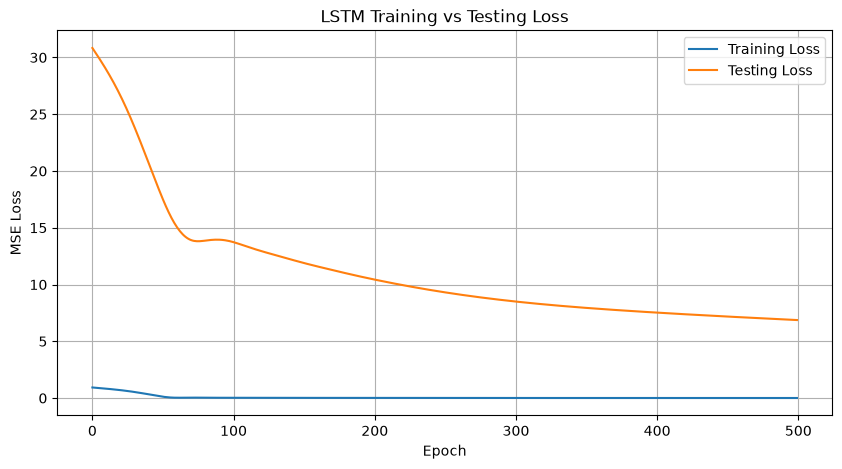

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_hist,
    label="Training Loss"
)

plt.plot(
    test_hist,
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Testing Loss")

plt.legend()
plt.grid(True)

plt.show()

In [65]:
print("Training Close range:")
print(series[:split].min(), series[:split].max())

print("\nTesting Close range:")
print(series[split:].min(), series[split:].max())

print("\nTraining mean:")
print(series[:split].mean())

print("\nTesting mean:")
print(series[split:].mean())

Training Close range:
6.358 45.2

Testing Close range:
39.2 106.7

Training mean:
18.62987

Testing mean:
60.273247
